In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str((Path.cwd().parent / "src").resolve()))

from leanmetric.data.load import get_path_from_env, load_data, save_dataframe
from leanmetric.data.preprocessing import preprocess_data
from leanmetric.data.feature_engineering import run_feature_engineering, add_sex_feature

RAW_DATA_PATH = get_path_from_env("RAW_DATA_PATH")
PROCESSED_DATA_PATH = get_path_from_env("PROCESSED_DATA_PATH")

### Data loading

In [2]:
df = load_data(RAW_DATA_PATH)

### Preprocess and Feature Engineering

In [3]:
df = add_sex_feature(df)
df = preprocess_data(df)
df = run_feature_engineering(df)

In [4]:
print(f"Shape of the dataset: {df.shape}\n")
print(f"Info of the dataset:\n{df.info()}\n")
print(f"Null values in the dataset:\n{df.isnull().sum()}\n")
print(f"Duplicated rows in the dataset: {df.duplicated().sum()}\n")

Shape of the dataset: (252, 36)

<class 'pandas.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   density                  252 non-null    float64 
 1   bodyfat                  252 non-null    float64 
 2   age                      252 non-null    int64   
 3   weight                   252 non-null    float64 
 4   height                   252 non-null    float64 
 5   neck                     252 non-null    float64 
 6   chest                    252 non-null    float64 
 7   abdomen                  252 non-null    float64 
 8   hip                      252 non-null    float64 
 9   thigh                    252 non-null    float64 
 10  knee                     252 non-null    float64 
 11  ankle                    252 non-null    float64 
 12  biceps                   252 non-null    float64 
 13  forearm                  252 non-null    fl

In [5]:
print(f"Summary statistics of the dataset:")
df.describe(include="all").T

Summary statistics of the dataset:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
density,252.0,NaN,NaN,NaN,1.055574,0.019031,0.995,1.0414,1.0549,1.0704,1.1089
bodyfat,252.0,NaN,NaN,NaN,19.150794,8.36874,0.0,12.475,19.2,25.3,47.5
age,252.0,NaN,NaN,NaN,44.884921,12.60204,22.0,35.75,43.0,54.0,81.0
weight,252.0,NaN,NaN,NaN,81.158679,13.330688,53.750652,72.121128,80.058988,89.357624,164.721935
height,252.0,NaN,NaN,NaN,178.177976,9.303654,74.93,173.355,177.8,183.515,197.485
neck,252.0,NaN,NaN,NaN,37.992063,2.430913,31.1,36.4,38.0,39.425,51.2
chest,252.0,NaN,NaN,NaN,100.824206,8.430476,79.3,94.35,99.65,105.375,136.2
abdomen,252.0,NaN,NaN,NaN,92.555952,10.783077,69.4,84.575,90.95,99.325,148.1
hip,252.0,NaN,NaN,NaN,99.904762,7.164058,85.0,95.5,99.3,103.525,147.7
thigh,252.0,NaN,NaN,NaN,59.405952,5.249952,47.2,56.0,59.0,62.35,87.3


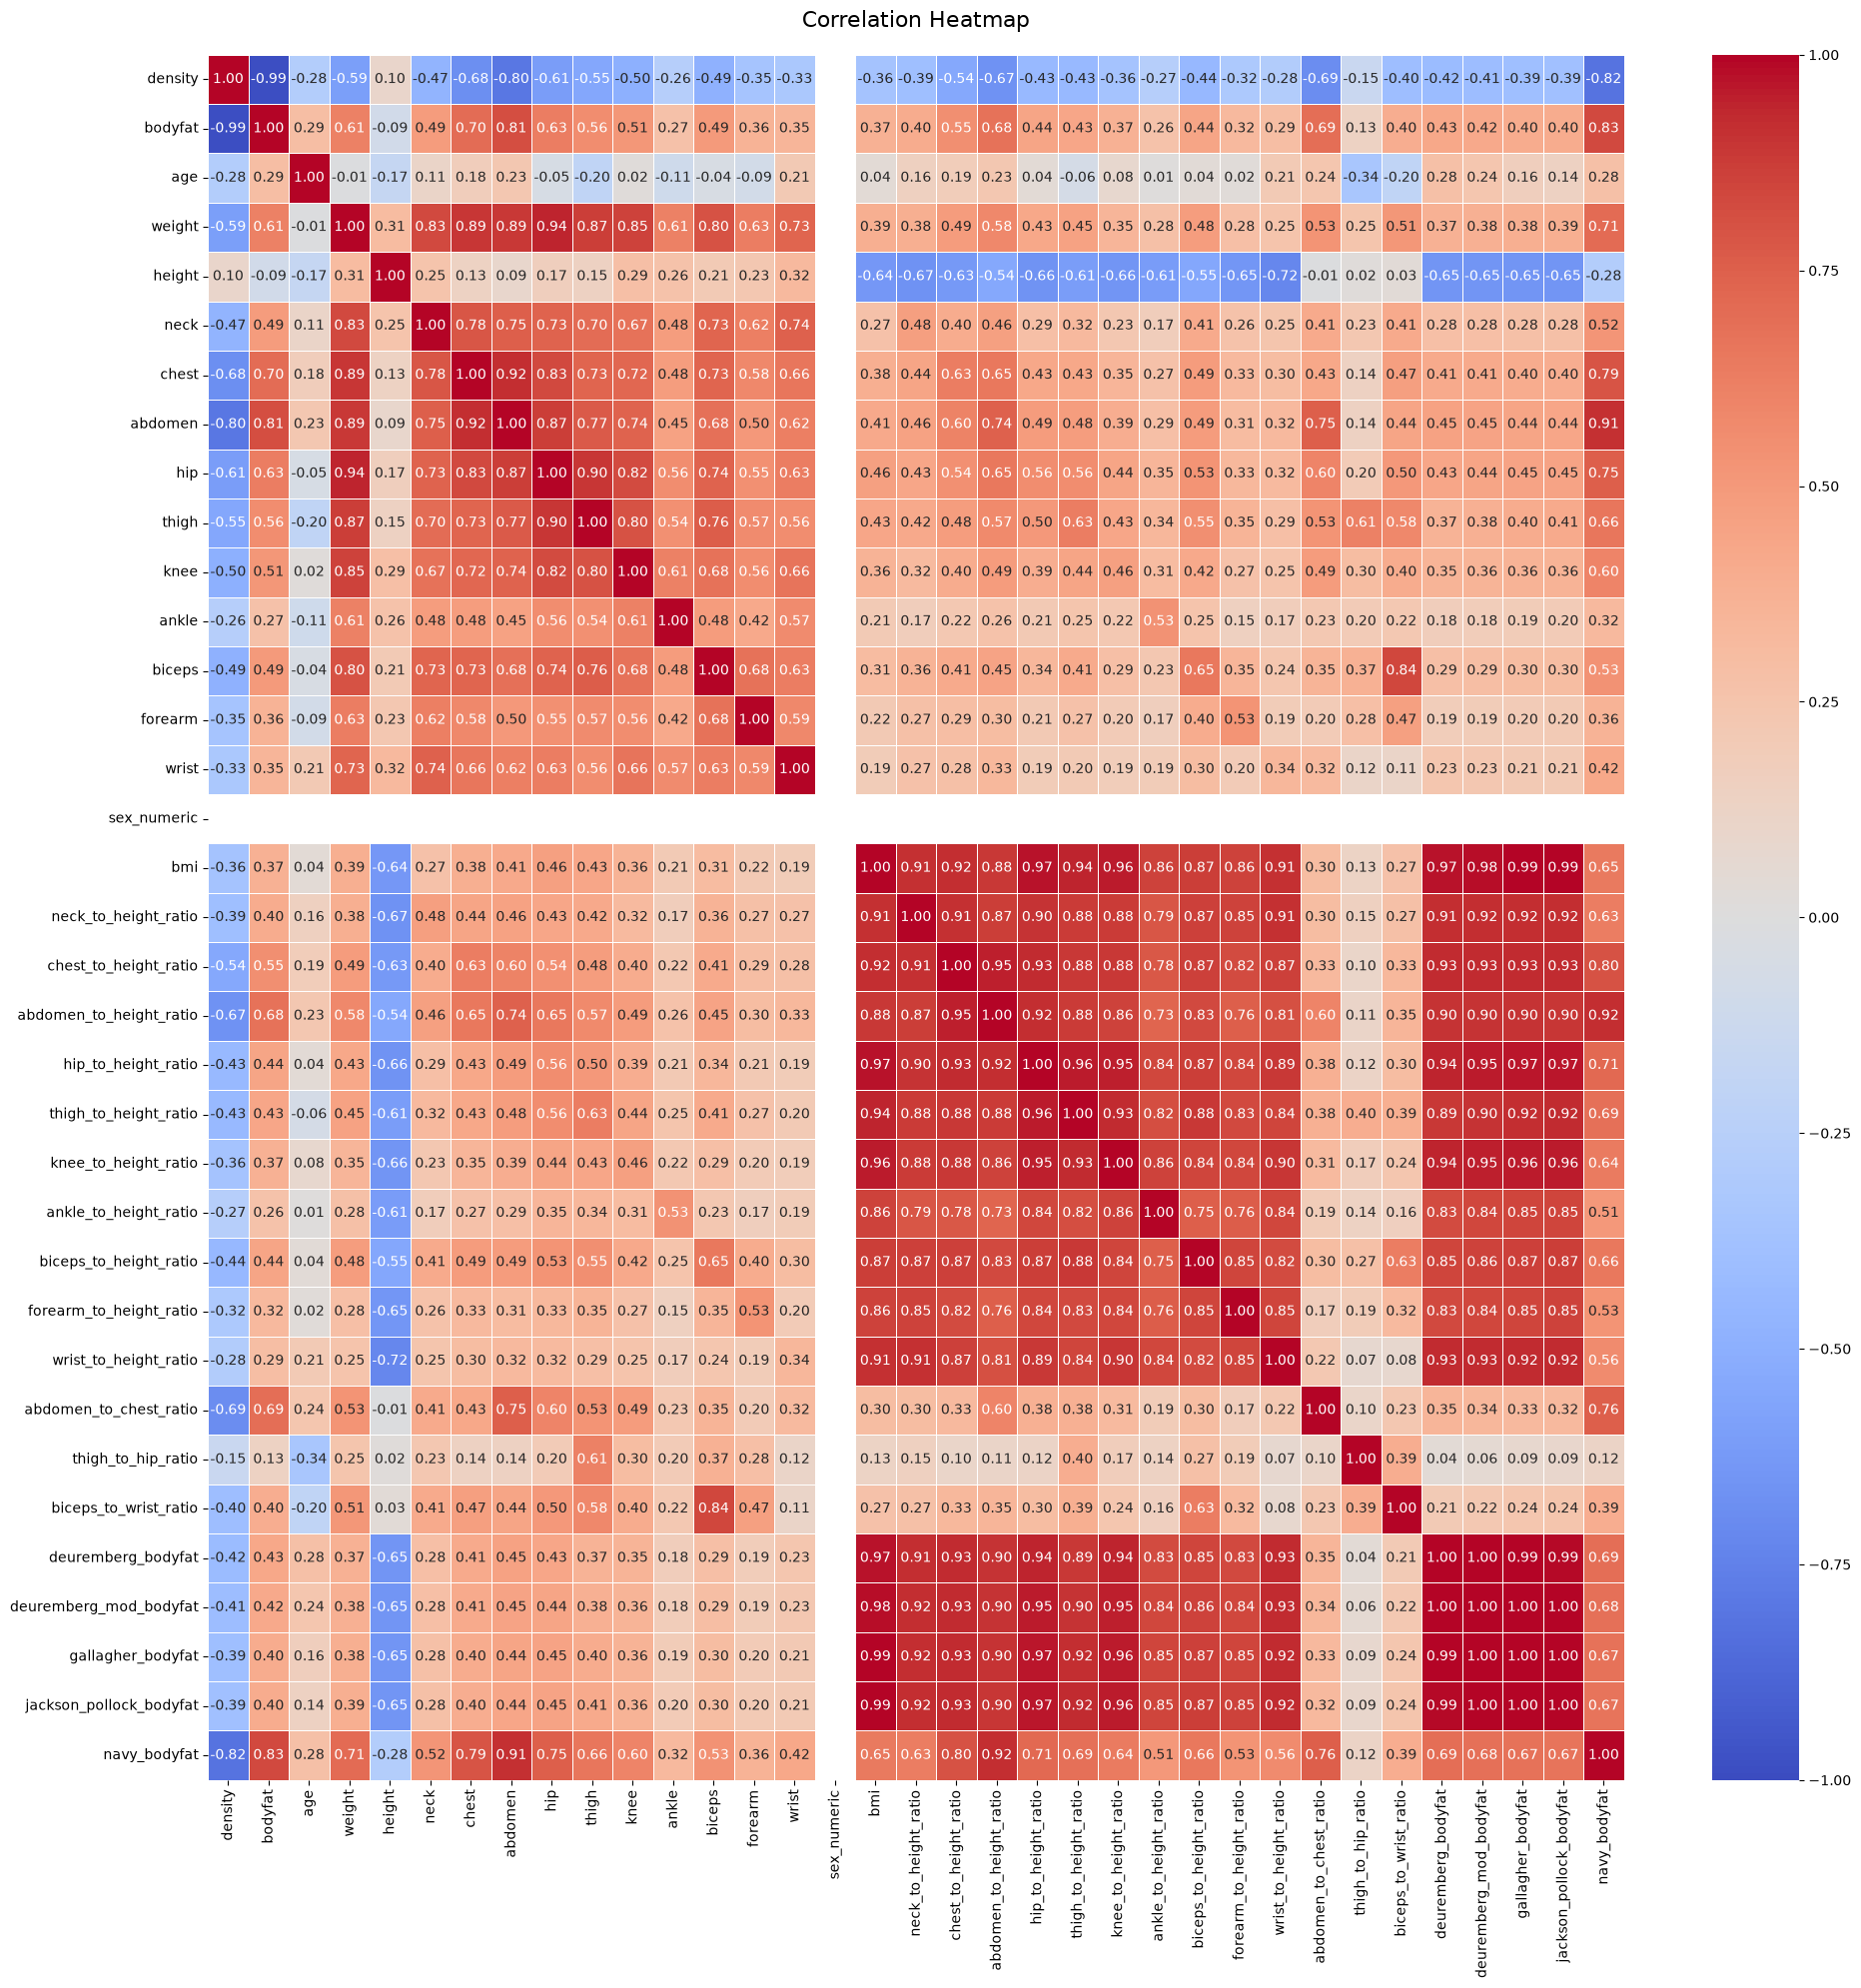

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=[np.number])
corr_df = numeric_df.corr()

fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(
    corr_df,
    ax=ax,
    annot=True,
    linewidths=0.5,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)
ax.set_title("Correlation Heatmap", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [7]:
corr_target = df.corr(numeric_only=True)["bodyfat"].sort_values(ascending=False)
print(f"Sorted features most correlated with Body Fat:\n{corr_target}\n")

Sorted features most correlated with Body Fat:
bodyfat                    1.000000
navy_bodyfat               0.829196
abdomen                    0.813432
chest                      0.702620
abdomen_to_chest_ratio     0.692835
abdomen_to_height_ratio    0.679573
hip                        0.625201
weight                     0.612414
thigh                      0.559608
chest_to_height_ratio      0.551338
knee                       0.508665
biceps                     0.493271
neck                       0.490592
biceps_to_height_ratio     0.441154
hip_to_height_ratio        0.439205
thigh_to_height_ratio      0.433178
deuremberg_bodyfat         0.427450
deuremberg_mod_bodyfat     0.418972
gallagher_bodyfat          0.403022
neck_to_height_ratio       0.400621
jackson_pollock_bodyfat    0.398491
biceps_to_wrist_ratio      0.397201
bmi                        0.371395
knee_to_height_ratio       0.369308
forearm                    0.361387
wrist                      0.346575
forearm_to_height

In [8]:
save_dataframe(df, PROCESSED_DATA_PATH)